In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
import torch
import json

from src.models.cbam_cnn import (
    CBAMCNN
)

from src.evaluation.evaluate import (
    evaluate_model
)

In [3]:
from src.preprocessing.dataset_loader import (
    build_dataset_index
)

from src.preprocessing.splitter import (
    create_stratified_split
)

from src.preprocessing.dataloaders import (
    create_datasets,
    create_dataloaders
)

In [4]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)

(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

(
    train_dataset,
    val_dataset,
    test_dataset
) = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

(
    train_loader,
    val_loader,
    test_loader
) = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset
)

In [5]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [6]:
model = CBAMCNN()

model.load_state_dict(
    torch.load(
        "../src/models/best_cbam_cnn.pth",
        map_location=device
    )
)

model.to(device)

C:\Users\gagan\AppData\Local\Temp\ipykernel_4684\1265976362.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


CBAMCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [7]:
metrics, cm, report = evaluate_model(
    model,
    test_loader,
    device
)

0.0003305470454506576 0.9999822378158569
0.3735782504081726 0.9999752044677734
0.0004507903940975666 0.9999480247497559
0.2839517295360565 0.9999275207519531
0.00023050584422890097 0.9999802112579346
0.2963623106479645 0.9999561309814453
7.654039654880762e-05 0.999993085861206
0.3578105568885803 0.9999861717224121
0.0001805803767638281 0.9999706745147705
0.31368279457092285 0.9999922513961792
0.0001404885551892221 0.9999891519546509
0.25098952651023865 0.9999794960021973
0.0005065519362688065 0.999927282333374
0.23736652731895447 0.9999314546585083
0.00015571233234368265 0.999923825263977
0.15004244446754456 0.9998664855957031
0.0003316812217235565 0.9995331764221191
0.34061866998672485 0.999718964099884
0.0002953863004222512 0.9997579455375671
0.12967908382415771 0.9998539686203003
0.0002953863004222512 0.9995830655097961
0.12967908382415771 0.9997743964195251
4.862676723860204e-05 0.9999260902404785
0.13769350945949554 0.9999444484710693
0.00027319631772115827 0.9998458623886108
0.16

In [8]:
print("\n=== CBAM TEST RESULTS ===\n")

for key, value in metrics.items():

    print(
        f"{key}: {value:.4f}"
    )


=== CBAM TEST RESULTS ===

accuracy: 0.8381
precision: 0.8068
recall: 0.9744
f1_score: 0.8827
roc_auc: 0.9359


In [9]:
print("\n=== CONFUSION MATRIX ===\n")

print(cm)


=== CONFUSION MATRIX ===

[[143  91]
 [ 10 380]]


In [10]:
print("\n=== CLASSIFICATION REPORT ===\n")

print(report)


=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       0.93      0.61      0.74       234
           1       0.81      0.97      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.79      0.81       624
weighted avg       0.85      0.84      0.83       624



In [11]:
with open(
    "../results/metrics/cbam_results.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

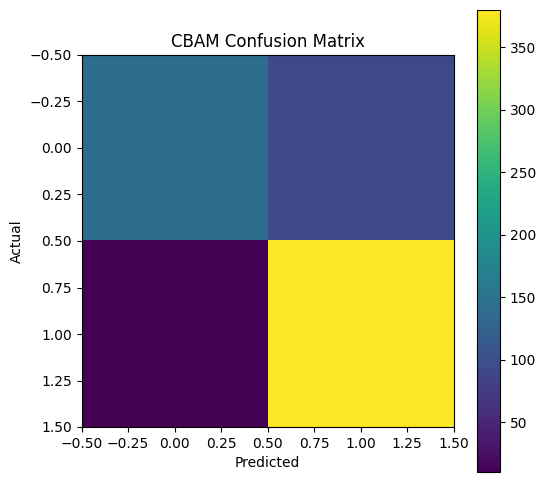

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title(
    "CBAM Confusion Matrix"
)

plt.colorbar()

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "../results/figures/cbam_confusion_matrix.png"
)

plt.show()